# Task 2

---

## Predictive modeling of customer bookings

This Jupyter notebook includes some code to get you started with this predictive modeling task. We will use various packages for data manipulation, feature engineering and machine learning.

### Exploratory data analysis

First, we must explore the data in order to better understand what we have and the statistical properties of the dataset.

In [114]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import LabelEncoder

In [115]:
df = pd.read_csv("customer_booking.csv", encoding="ISO-8859-1")
df.head()

,num_passengers,sales_channel,trip_type,purchase_lead,length_of_stay,flight_hour,flight_day,route,booking_origin,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,booking_complete
0,2,Internet,RoundTrip,262,19,7,Sat,AKLDEL,New Zealand,1,0,0,5.52,0
1,1,Internet,RoundTrip,112,20,3,Sat,AKLDEL,New Zealand,0,0,0,5.52,0
2,2,Internet,RoundTrip,243,22,17,Wed,AKLDEL,India,1,1,0,5.52,0
3,1,Internet,RoundTrip,96,31,4,Sat,AKLDEL,New Zealand,0,0,1,5.52,0
4,2,Internet,RoundTrip,68,22,15,Wed,AKLDEL,India,1,0,1,5.52,0


The `.head()` method allows us to view the first 5 rows in the dataset, this is useful for visual inspection of our columns

In [116]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   num_passengers         50000 non-null  int64  
 1   sales_channel          50000 non-null  object 
 2   trip_type              50000 non-null  object 
 3   purchase_lead          50000 non-null  int64  
 4   length_of_stay         50000 non-null  int64  
 5   flight_hour            50000 non-null  int64  
 6   flight_day             50000 non-null  object 
 7   route                  50000 non-null  object 
 8   booking_origin         50000 non-null  object 
 9   wants_extra_baggage    50000 non-null  int64  
 10  wants_preferred_seat   50000 non-null  int64  
 11  wants_in_flight_meals  50000 non-null  int64  
 12  flight_duration        50000 non-null  float64
 13  booking_complete       50000 non-null  int64  
dtypes: float64(1), int64(8), object(5)
memory usage: 5.3+ 

The `.info()` method gives us a data description, telling us the names of the columns, their data types and how many null values we have. Fortunately, we have no null values. It looks like some of these columns should be converted into different data types, e.g. flight_day.

To provide more context, below is a more detailed data description, explaining exactly what each column means:

- `num_passengers` = number of passengers travelling
- `sales_channel` = sales channel booking was made on
- `trip_type` = trip Type (Round Trip, One Way, Circle Trip)
- `purchase_lead` = number of days between travel date and booking date
- `length_of_stay` = number of days spent at destination
- `flight_hour` = hour of flight departure
- `flight_day` = day of week of flight departure
- `route` = origin -> destination flight route
- `booking_origin` = country from where booking was made
- `wants_extra_baggage` = if the customer wanted extra baggage in the booking
- `wants_preferred_seat` = if the customer wanted a preferred seat in the booking
- `wants_in_flight_meals` = if the customer wanted in-flight meals in the booking
- `flight_duration` = total duration of flight (in hours)
- `booking_complete` = flag indicating if the customer completed the booking

Before we compute any statistics on the data, lets do any necessary data conversion

In [117]:
df["flight_day"].unique()

array(['Sat', 'Wed', 'Thu', 'Mon', 'Sun', 'Tue', 'Fri'], dtype=object)

In [118]:
mapping = {
    "Mon": 1,
    "Tue": 2,
    "Wed": 3,
    "Thu": 4,
    "Fri": 5,
    "Sat": 6,
    "Sun": 7,
}

df["flight_day"] = df["flight_day"].map(mapping)

In [119]:
df["flight_day"].unique()

array([6, 3, 4, 1, 7, 2, 5], dtype=int64)

In [120]:
df.describe()

,num_passengers,purchase_lead,length_of_stay,flight_hour,flight_day,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,booking_complete
count,50000.000000,50000.000000,50000.00000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,1.591240,84.940480,23.04456,9.06634,3.814420,0.668780,0.296960,0.427140,7.277561,0.149560
std,1.020165,90.451378,33.88767,5.41266,1.992792,0.470657,0.456923,0.494668,1.496863,0.356643
min,1.000000,0.000000,0.00000,0.00000,1.000000,0.000000,0.000000,0.000000,4.670000,0.000000
25%,1.000000,21.000000,5.00000,5.00000,2.000000,0.000000,0.000000,0.000000,5.620000,0.000000
50%,1.000000,51.000000,17.00000,9.00000,4.000000,1.000000,0.000000,0.000000,7.570000,0.000000
75%,2.000000,115.000000,28.00000,13.00000,5.000000,1.000000,1.000000,1.000000,8.830000,0.000000
max,9.000000,867.000000,778.00000,23.00000,7.000000,1.000000,1.000000,1.000000,9.500000,1.000000


The `.describe()` method gives us a summary of descriptive statistics over the entire dataset (only works for numeric columns). This gives us a quick overview of a few things such as the mean, min, max and overall distribution of each column.

From this point, you should continue exploring the dataset with some visualisations and other metrics that you think may be useful. Then, you should prepare your dataset for predictive modelling. Finally, you should train your machine learning model, evaluate it with performance metrics and output visualisations for the contributing variables. All of this analysis should be summarised in your single slide.

In [121]:
df.shape

(50000, 14)

In [122]:
df.isnull().sum()

num_passengers           0
sales_channel            0
trip_type                0
purchase_lead            0
length_of_stay           0
flight_hour              0
flight_day               0
route                    0
booking_origin           0
wants_extra_baggage      0
wants_preferred_seat     0
wants_in_flight_meals    0
flight_duration          0
booking_complete         0
dtype: int64

In [123]:
df.columns

Index(['num_passengers', 'sales_channel', 'trip_type', 'purchase_lead',
       'length_of_stay', 'flight_hour', 'flight_day', 'route',
       'booking_origin', 'wants_extra_baggage', 'wants_preferred_seat',
       'wants_in_flight_meals', 'flight_duration', 'booking_complete'],
      dtype='object')

<Axes: xlabel='booking_complete'>

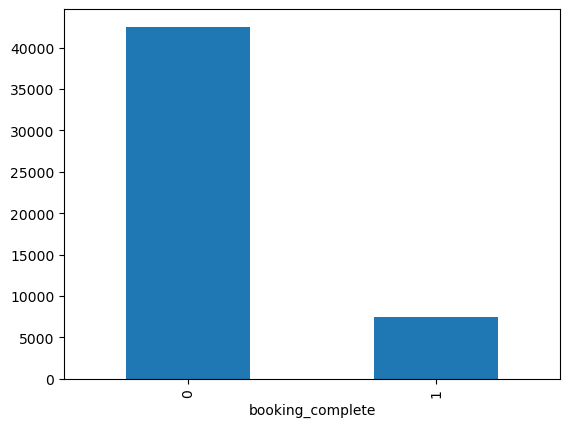

In [124]:
df['booking_complete'].value_counts().plot(kind='bar')

<Axes: xlabel='sales_channel'>

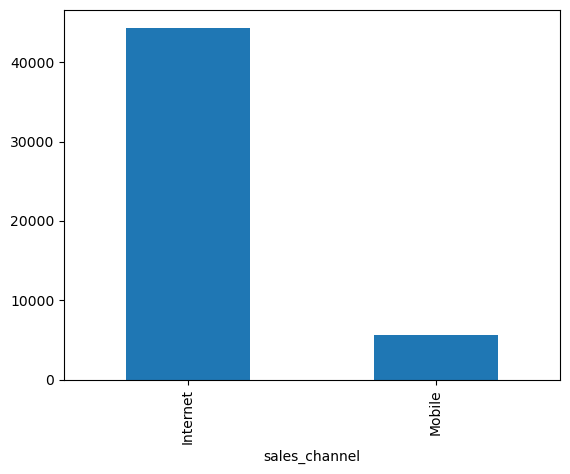

In [125]:
df['sales_channel'].value_counts().plot(kind='bar')

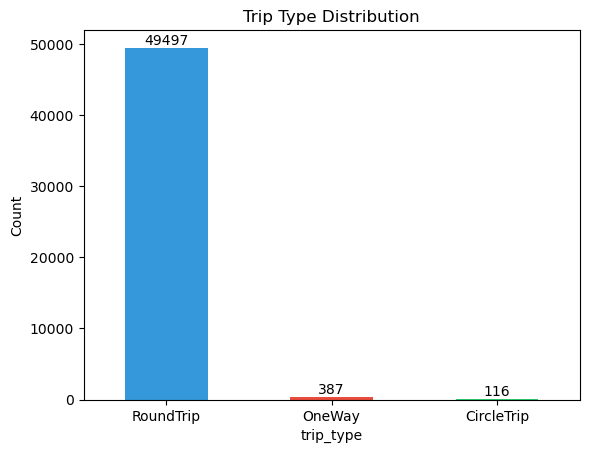

In [126]:
ax = df['trip_type'].value_counts().plot(kind='bar', color=['#3498db','#e74c3c','#2ecc71'])

for p in ax.patches:
    ax.annotate(str(p.get_height()), 
                (p.get_x() + p.get_width()/2, p.get_height()), 
                ha='center', va='bottom')

plt.title('Trip Type Distribution')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

<Axes: xlabel='route'>

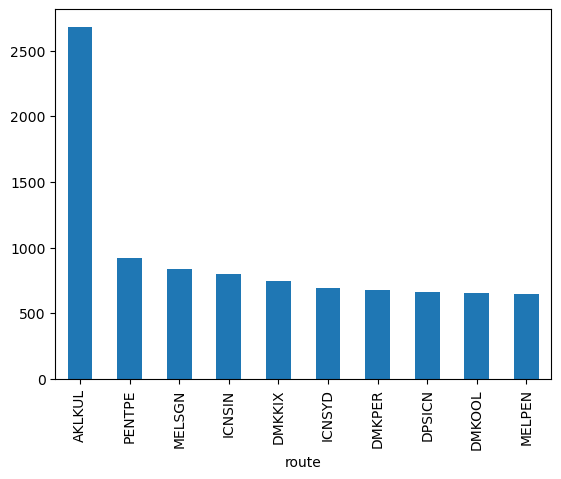

In [127]:
df['route'].value_counts().head(10).plot(kind='bar')

<Axes: xlabel='booking_origin'>

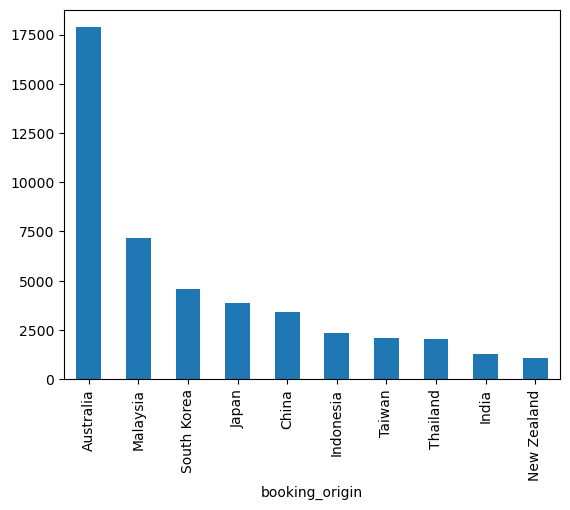

In [128]:
df['booking_origin'].value_counts().head(10).plot(kind ='bar')

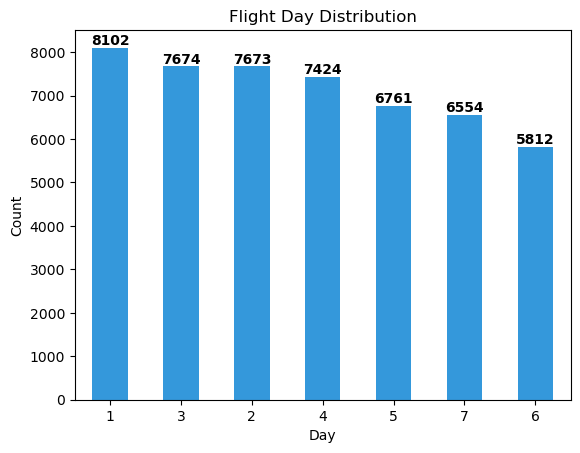

In [129]:
ax = df['flight_day'].value_counts().plot(kind='bar', color='#3498db')

for p in ax.patches:
    ax.annotate(str(p.get_height()), 
                (p.get_x() + p.get_width()/2, p.get_height()), 
                ha='center', va='bottom', fontweight='bold')

plt.title('Flight Day Distribution')
plt.ylabel('Count')
plt.xlabel('Day')
plt.xticks(rotation=0)
plt.show()

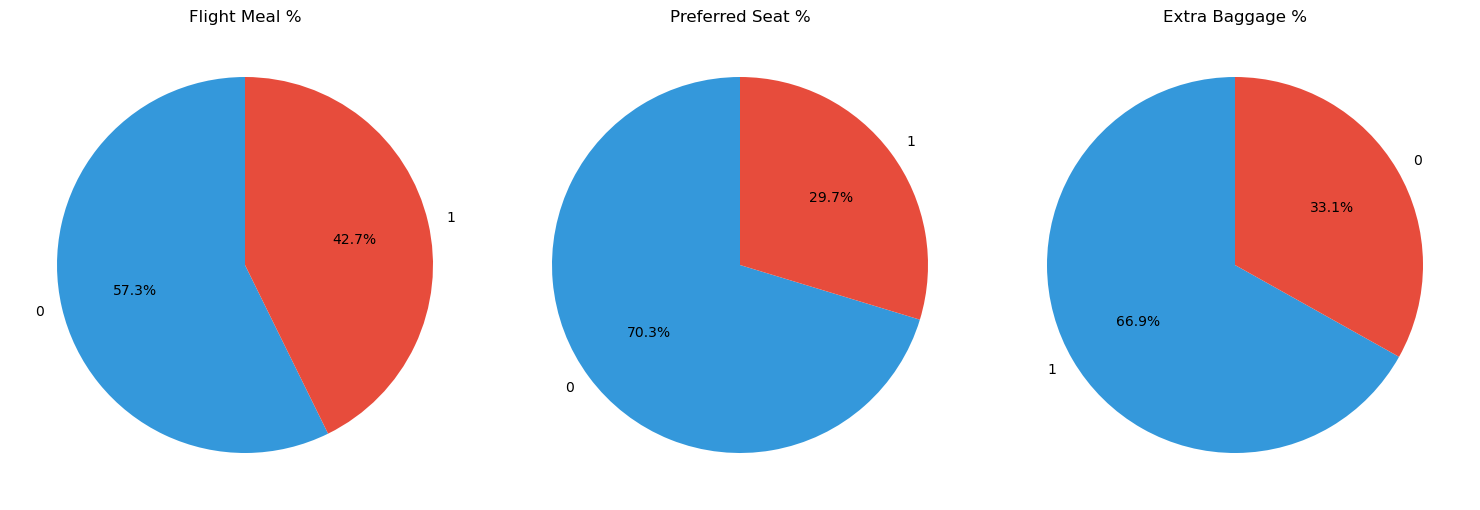

In [130]:
pie_cols = {
    'wants_in_flight_meals': 'Flight Meal %',
    'wants_preferred_seat': 'Preferred Seat %',
    'wants_extra_baggage': 'Extra Baggage %'
}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (col, title) in zip(axes, pie_cols.items()):
    df[col].value_counts().plot(
        kind='pie',
        autopct='%1.1f%%',
        colors=['#3498db', '#e74c3c'],
        startangle=90,
        ax=ax
    )
    ax.set_title(title)
    ax.set_ylabel('')

plt.tight_layout()
plt.show()

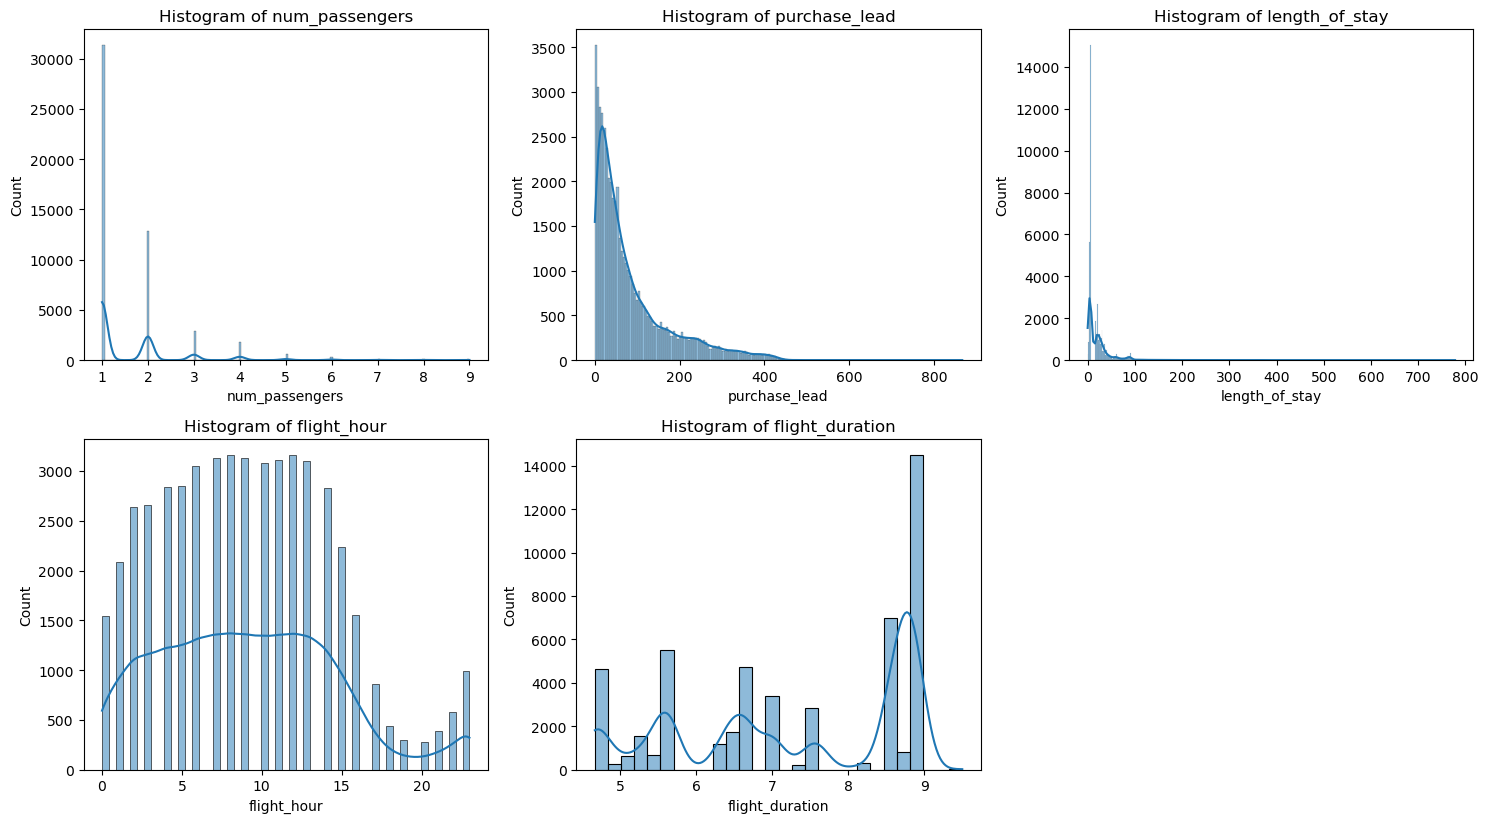

In [131]:
num_cols = ['num_passengers','purchase_lead','length_of_stay', 'flight_hour','flight_duration']
plt.figure(figsize=(15, 12))
for i, col in enumerate(num_cols, 1):
    plt.subplot(3, 3, i)
    sns.histplot(df[col], kde=True)
    plt.title(f'Histogram of {col}')
    
plt.tight_layout()

### Observations from EDA
1. Target Variable (booking_complete)
* Only 15% customers completed booking — dataset is heavily imbalanced
* 42,522 did NOT book vs only 7,478 who booked

2. num_passengers
* Most travelers are solo (1 passenger) — over 30,000 out of 50,000
* Group travel (3+ passengers) is very rare
* Max is 9 passengers but extremely uncommon

3. purchase_lead
* Average booking is made 85 days before travel
* Most customers book within 0-100 days — last minute trend
* Max is 867 days — clear outlier, very unusual

4. length_of_stay
* Average stay is 23 days but median is only 17 days
* Max is 778 days — extreme outlier, likely data error
* Most customers prefer short stays under 50 days

5. flight_hour
* Flights are mostly scheduled between 8 AM to 3 PM
* Very few flights depart after 9 PM or before 5 AM
* Distribution follows a bell curve shape

6. flight_day
* Monday and Wednesday have highest flight frequency
* Saturday has the lowest number of flights
* Weekday travel dominates over weekends

7. flight_duration
* Two clear peaks — 5-6 hours and 8-9 hours
* Suggests BA operates two main route types:
* Short haul (~5 hrs) → nearby Asia
* Long haul (~9 hrs) → USA/Europe

8. wants_extra_baggage
* 67% customers want extra baggage — majority feature
* Strong add-on preference among BA customers

9. wants_preferred_seat
* Only 30% customers want preferred seat
* Less popular add-on compared to baggage

10. wants_in_flight_meals
* 43% customers want in-flight meals
* Moderate demand — almost half of customers

In [132]:
# Pehle dekho kitne outliers hain
print("purchase_lead > 400:", (df['purchase_lead'] > 400).sum())
print("length_of_stay > 200:", (df['length_of_stay'] > 200).sum())

purchase_lead > 400: 386
length_of_stay > 200: 279


In [133]:
df['num_passengers'].value_counts()

num_passengers
1    31352
2    12804
3     2941
4     1784
5      561
6      289
7      114
8       89
9       66
Name: count, dtype: int64

In [134]:
Q1 = df['num_passengers'].quantile(0.25)
Q3 = df['num_passengers'].quantile(0.75)
IQR = Q3 - Q1
upper_limit = Q3 + 1.5 * IQR
print("Upper limit:", upper_limit)
print("Outliers count:", (df['num_passengers'] > upper_limit).sum())

Upper limit: 3.5
Outliers count: 2903


In [135]:
mean_val = round(df['num_passengers'].mean())
df['num_passengers'] = df['num_passengers'].apply(lambda x: mean_val if x > upper_limit else x)

In [136]:
Q1 = df['purchase_lead'].quantile(0.25)
Q3 = df['purchase_lead'].quantile(0.75)
IQR = Q3 - Q1
upper_limit_pl = Q3 + 1.5 * IQR
print("Upper limit:", upper_limit_pl)
print("Outliers count:", (df['purchase_lead'] > upper_limit_pl).sum())

Upper limit: 256.0
Outliers count: 3456


In [137]:
mean_val_pl = round(df['purchase_lead'].mean())
df['purchase_lead'] = df['purchase_lead'].apply(lambda x: mean_val_pl if x > upper_limit_pl else x)

In [138]:
Q1 = df['length_of_stay'].quantile(0.25)
Q3 = df['length_of_stay'].quantile(0.75)
IQR = Q3 - Q1
upper_limit_los = Q3 + 1.5 * IQR

print("Upper limit:", upper_limit_los)
print("Outliers count:", (df['length_of_stay'] > upper_limit_los).sum())

Upper limit: 62.5
Outliers count: 3807


In [139]:
mean_val_los = round(df['length_of_stay'].mean())
df['length_of_stay'] = df['length_of_stay'].apply(lambda x: mean_val_los if x > upper_limit_los else x)

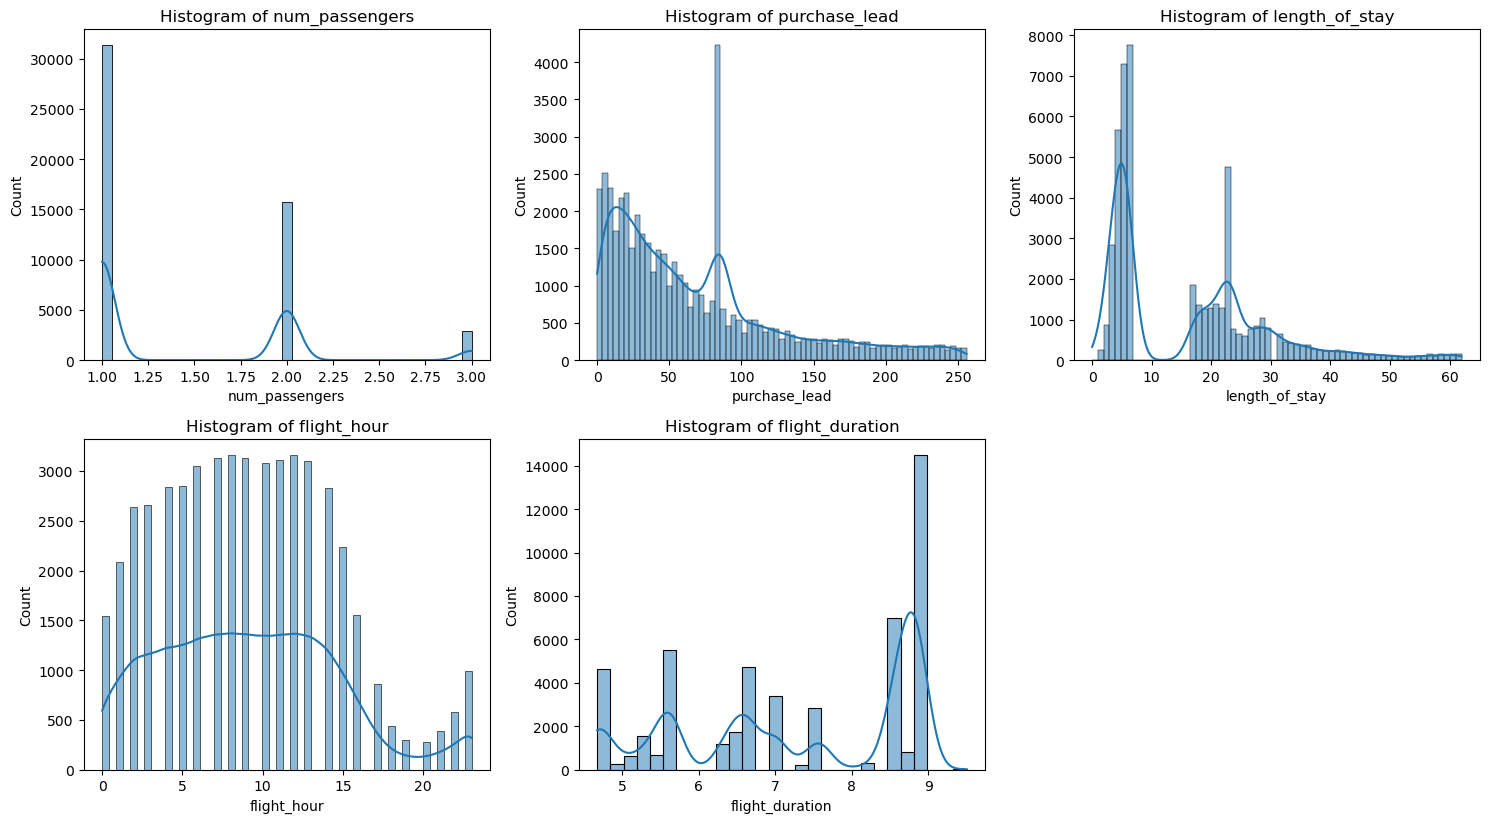

In [140]:
num_cols = ['num_passengers','purchase_lead','length_of_stay', 'flight_hour','flight_duration']
plt.figure(figsize=(15, 12))
for i, col in enumerate(num_cols, 1):
    plt.subplot(3, 3, i)
    sns.histplot(df[col], kde=True)
    plt.title(f'Histogram of {col}')
    
plt.tight_layout()

In [141]:
print("Before:")
print(df['booking_complete'].value_counts())
print(df['booking_complete'].value_counts(normalize=True)*100)

Before:
booking_complete
0    42522
1     7478
Name: count, dtype: int64
booking_complete
0    85.044
1    14.956
Name: proportion, dtype: float64
